# Campaign results rendering

This notebook plots fidelity differences with confidence intervals using results from `campaign_tests.csv`.

Notes:
- The CIs in `campaign_tests.csv` refer to the mean difference (delta) between groups.
- Plots below show deltas with CI error bars.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
tests_path = 'results/campaign_tests.csv'
tests = pd.read_csv(tests_path)
tests['p_depol'] = tests['p_depol'].astype(float)
tests.head()


,test,p_depol,context,group_a,group_b,n,t_stat,df,p_value,alpha,reject_h0,mean_a,mean_b,mean_diff,ci_low,ci_high
0,paired_cutoff,0.02,N_MEM=5,off,on,30,-116.705575,29.000000,2.589110e-40,0.05,True,0.778872,0.901627,-0.122755,-0.124906,-0.120603
1,paired_cutoff,0.05,N_MEM=5,off,on,30,-83.213540,29.000000,4.577977e-36,0.05,True,0.731677,0.843674,-0.111997,-0.114750,-0.109245
2,paired_cutoff,0.10,N_MEM=5,off,on,30,-100.371415,29.000000,2.030300e-38,0.05,True,0.659735,0.754460,-0.094725,-0.096655,-0.092795
3,welch_mem,0.02,cutoff_off,5,10,30,40.328844,57.319615,9.044919e-44,0.05,True,0.778872,0.709225,0.069647,0.066189,0.073104
4,welch_mem,0.02,cutoff_off,5,20,30,79.085634,56.943376,6.434174e-60,0.05,True,0.778872,0.640154,0.138718,0.135205,0.142230


## Cutoff on/off: one plot per p_depol

Each plot shows the delta `on - off` with its CI from the paired test.


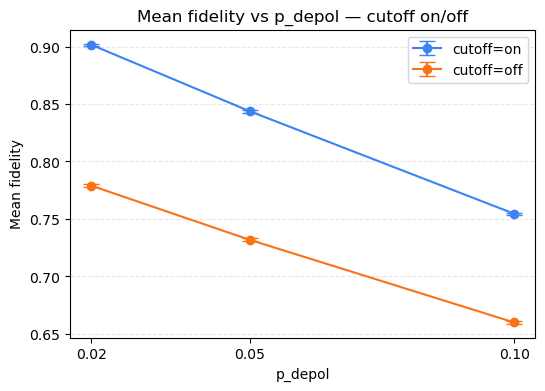

In [23]:
cutoff = tests[tests['test'] == 'paired_cutoff'].copy()
cutoff = cutoff.sort_values('p_depol')
# Estimate individual mean errors from the reported CI on the difference (approximation)
delta_ci_half = (cutoff['ci_high'] - cutoff['ci_low']) / 2.0
cutoff['mean_a_err'] = delta_ci_half / 2.0
cutoff['mean_b_err'] = delta_ci_half / 2.0

# Single plot: mean fidelity vs p_depol with two lines (cutoff on / off)
p_vals = cutoff['p_depol'].values
mean_off = cutoff['mean_a'].values  # 'off' corresponds to mean_a in the paired test
mean_on = cutoff['mean_b'].values   # 'on' corresponds to mean_b
err_off = cutoff['mean_a_err'].values
err_on = cutoff['mean_b_err'].values

fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(p_vals, mean_on, yerr=err_on, marker='o', label='cutoff=on', color='#3b82f6', capsize=6)
ax.errorbar(p_vals, mean_off, yerr=err_off, marker='o', label='cutoff=off', color='#f97316', capsize=6)
ax.set_xticks(p_vals)
ax.set_xlabel('p_depol')
ax.set_ylabel('Mean fidelity')
ax.set_title('Mean fidelity vs p_depol — cutoff on/off')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


## Memory comparison (p_depol=0.02, cutoff off)

These are Welch comparisons between memory sizes. Bars show deltas with CI.


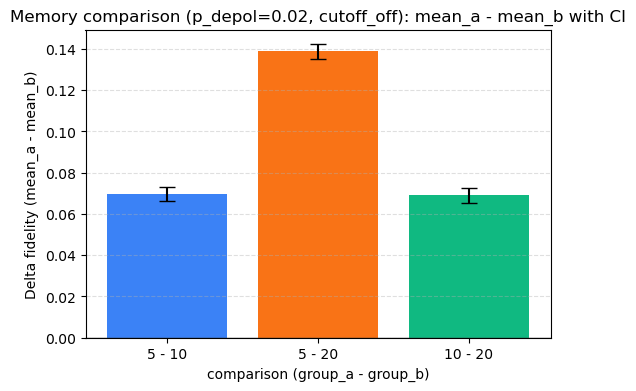

In [27]:
# Memory comparison (p_depol=0.02, cutoff off) - plot deltas (mean_diff) with CI from campaign_tests.csv
mem = tests[(tests['test'] == 'welch_mem') & (tests['p_depol'] == 0.02)].copy()
mem['label'] = mem['group_a'].astype(str) + ' - ' + mem['group_b'].astype(str)
# Use mean_diff and its CI directly (these are group_a - group_b)
deltas = mem['mean_diff'].values
ci_low = mem['ci_low'].values
ci_high = mem['ci_high'].values
yerr = [deltas - ci_low, ci_high - deltas]

fig, ax = plt.subplots(figsize=(6, 4))
# three distinct colors (blue/orange/green). If number of bars differs, fall back to tab10 palette
colors = ['#3b82f6', '#f97316', '#10b981']
if len(mem) != len(colors):
    from matplotlib import cm
    colors = cm.tab10.colors[:len(mem)]
ax.bar(mem['label'], deltas, yerr=yerr, capsize=6, color=colors)
ax.axhline(0, color='#444444', linewidth=1)
ax.set_title('Memory comparison (p_depol=0.02, cutoff_off): mean_a - mean_b with CI')
ax.set_xlabel('comparison (group_a - group_b)')
ax.set_ylabel('Delta fidelity (mean_a - mean_b)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


## Tables

Quick tables for reference.


In [25]:
cutoff[['p_depol', 'mean_a', 'mean_b', 'mean_diff', 'ci_low', 'ci_high', 'p_value']]


,p_depol,mean_a,mean_b,mean_diff,ci_low,ci_high,p_value
0,0.02,0.778872,0.901627,-0.122755,-0.124906,-0.120603,2.589110e-40
1,0.05,0.731677,0.843674,-0.111997,-0.114750,-0.109245,4.577977e-36
2,0.10,0.659735,0.754460,-0.094725,-0.096655,-0.092795,2.030300e-38


In [26]:
mem[['p_depol', 'group_a', 'group_b', 'mean_diff', 'ci_low', 'ci_high', 'p_value']]


,p_depol,group_a,group_b,mean_diff,ci_low,ci_high,p_value
3,0.02,5,10,0.069647,0.066189,0.073104,9.044919e-44
4,0.02,5,20,0.138718,0.135205,0.142230,6.434174e-60
5,0.02,10,20,0.069071,0.065379,0.072763,2.613915e-42


## Additional views

Forest plot, distribution boxplots, and a ranked effects table.

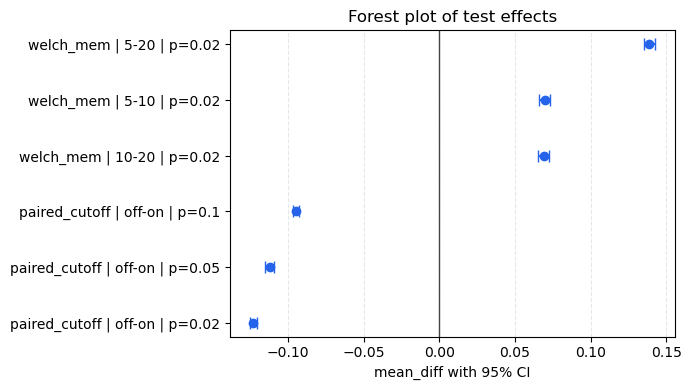

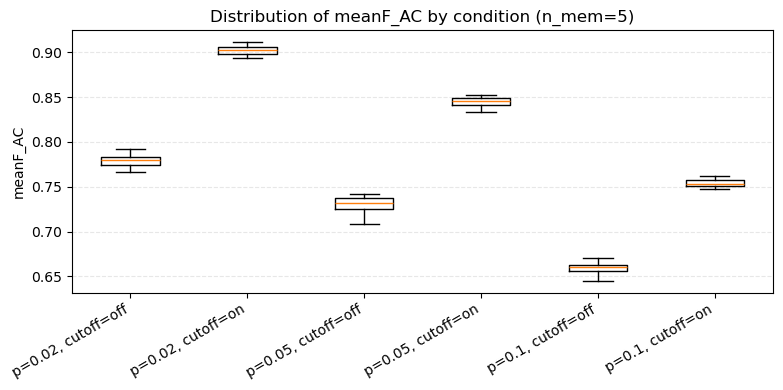

,test,p_depol,group_a,group_b,mean_diff,ci_low,ci_high,p_value
0,welch_mem,0.02,5,20,0.138718,0.135205,0.142230,6.434174e-60
1,paired_cutoff,0.02,off,on,-0.122755,-0.124906,-0.120603,2.589110e-40
2,paired_cutoff,0.05,off,on,-0.111997,-0.114750,-0.109245,4.577977e-36
3,paired_cutoff,0.10,off,on,-0.094725,-0.096655,-0.092795,2.030300e-38
4,welch_mem,0.02,5,10,0.069647,0.066189,0.073104,9.044919e-44
5,welch_mem,0.02,10,20,0.069071,0.065379,0.072763,2.613915e-42


In [29]:
import numpy as np

# 1) Forest plot of mean differences (from campaign_tests.csv)
plot_df = tests.copy()
plot_df['label'] = plot_df.apply(
    lambda r: f"{r['test']} | {r['group_a']}-{r['group_b']} | p={r['p_depol']}", axis=1
 )
plot_df = plot_df.sort_values('mean_diff')
x = plot_df['mean_diff'].values
xerr_left = x - plot_df['ci_low'].values
xerr_right = plot_df['ci_high'].values - x
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(x, y, xerr=[xerr_left, xerr_right], fmt='o', color='#2563eb', capsize=4)
ax.axvline(0, color='#444444', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['label'])
ax.set_xlabel('mean_diff with 95% CI')
ax.set_title('Forest plot of test effects')
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Boxplot of meanF_AC by condition (p_depol x cutoff) for n_mem=5
runs = pd.read_csv('campaign_runs.csv')
runs['p_depol'] = runs['p_depol'].astype(float)
runs['cutoff_active'] = runs['cutoff_active'].astype(float)
runs_5 = runs[runs['n_mem'] == 5.0].copy()
runs_5['label'] = runs_5.apply(
    lambda r: f"p={r['p_depol']}, cutoff={'on' if r['cutoff_active'] == 1.0 else 'off'}", axis=1
 )
labels = sorted(runs_5['label'].unique(), key=lambda s: (float(s.split('=')[1].split(',')[0]), s))
data = [runs_5[runs_5['label'] == lab]['meanF_AC'].values for lab in labels]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, tick_labels=labels, showfliers=False)
ax.set_title('Distribution of meanF_AC by condition (n_mem=5)')
ax.set_ylabel('meanF_AC')
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Ranking table of effects by absolute mean_diff
rank = tests.copy()
rank['abs_diff'] = rank['mean_diff'].abs()
rank = rank.sort_values('abs_diff', ascending=False)
rank[['test', 'p_depol', 'group_a', 'group_b', 'mean_diff', 'ci_low', 'ci_high', 'p_value']].reset_index(drop=True)
